<a href="https://colab.research.google.com/github/TimofeyProtasov/diploma/blob/main/days/second_graphics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
def load_all_results(save_dir: str, path="results_train_*.csv") -> pd.DataFrame:
    all_files = Path(save_dir).glob(path)
    df_list = []
    for file in all_files:
        df = pd.read_csv(file)
        df_list.append(df)
    if df_list:
        return pd.concat(df_list, ignore_index=True)
    else:
        return pd.DataFrame()


# lora gold


In [ ]:
df_all = load_all_results("/content/drive/MyDrive/rag_experiments_second", "results_train_*_lora_config.csv")
print(df_all)

   train_size  trainable_params_m  before_train_peak_memory_gb  \
0         100            8.798208                         2.47   
1         300            8.798208                         2.47   
2         500            8.798208                         2.47   
3         700            8.798208                         2.47   
4         900            8.798208                         2.47   

   train_time_min  train_peak_memory_gb    f1  evaluate_f1_time_min  \
0            0.86                 10.98  0.59                  4.88   
1            2.52                 11.02  0.67                  4.19   
2            4.25                 11.02  0.74                  4.28   
3            5.97                 11.02  0.66                  4.06   
4            7.60                 11.02  0.75                  4.26   

   evaluate_f1_peak_memory_gb  perplexity  evaluate_perplexity_time_min  ...  \
0                        2.78        1.58                          0.16  ...   
1               

In [ ]:

# 1. Вручную соберём длинный формат
records = []
for _, row in df_all.iterrows():
    train_size = row['train_size']
    for ep in [4, 6, 8, 10, 12, 14]:
        records.append({
            'train_size': train_size,
            'epoch': ep,
            'f1': row[f'f1_epoch{ep}'],
            'perplexity': row[f'perplexity_epoch{ep}'],
            'f1_time': row[f'f1_time_epoch{ep}'],
            'f1_memory': row[f'f1_memory_epoch{ep}'],
            'perplexity_time': row[f'perplexity_time_epoch{ep}'],
            'perplexity_memory': row[f'perplexity_memory_epoch{ep}'],
            'train_time': row['train_time_min'],
            'train_memory': row['train_peak_memory_gb']
        })

df_long = pd.DataFrame(records)


In [ ]:
df_long

,train_size,epoch,f1,perplexity,f1_time,f1_memory,perplexity_time,perplexity_memory,train_time,train_memory
0,100.0,4,0.45,1.61,5.15,2.78,0.16,4.60,0.86,10.98
1,100.0,6,0.61,1.59,4.74,2.78,0.15,4.60,0.86,10.98
2,100.0,8,0.58,1.59,4.74,2.78,0.16,4.60,0.86,10.98
3,100.0,10,0.59,1.58,4.98,2.78,0.16,4.60,0.86,10.98
4,100.0,12,0.58,1.58,5.03,2.78,0.16,4.60,0.86,10.98
5,100.0,14,0.59,1.58,4.88,2.78,0.16,4.60,0.86,10.98
6,300.0,4,0.60,1.53,3.76,2.67,0.16,4.48,2.52,11.02
7,300.0,6,0.62,1.53,4.24,2.67,0.16,4.48,2.52,11.02
8,300.0,8,0.65,1.53,3.94,2.67,0.16,4.48,2.52,11.02
9,300.0,10,0.61,1.53,4.25,2.67,0.16,4.48,2.52,11.02


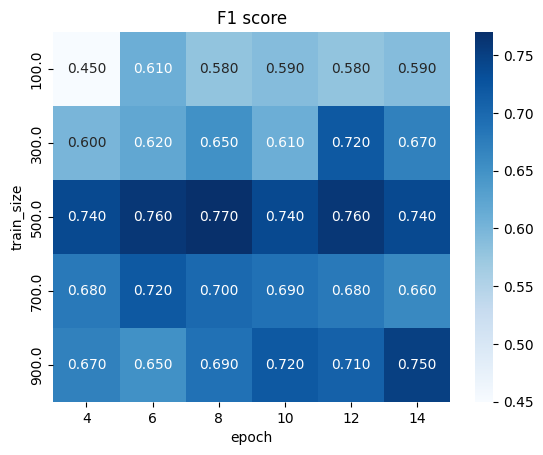

In [ ]:

# 2. Heatmap (пример для f1)
pivot_f1 = df_long.pivot(index='train_size', columns='epoch', values='f1')
sns.heatmap(pivot_f1, annot=True, fmt='.3f', cmap='Blues')
plt.title('F1 score')
plt.show()


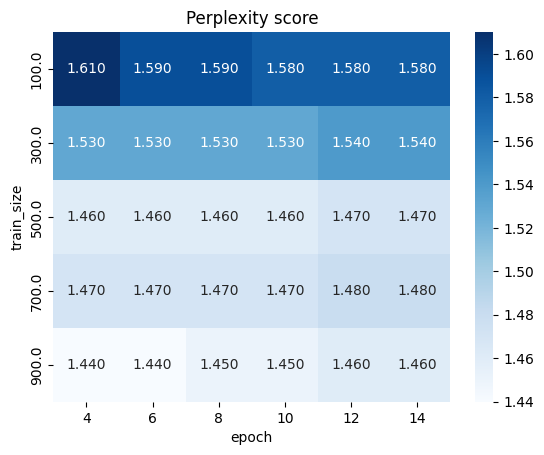

In [ ]:

# 2. Heatmap (пример для Perplexity)
pivot_per = df_long.pivot(index='train_size', columns='epoch', values='perplexity')
sns.heatmap(pivot_per, annot=True, fmt='.3f', cmap='Blues')
plt.title('Perplexity score')
plt.show()


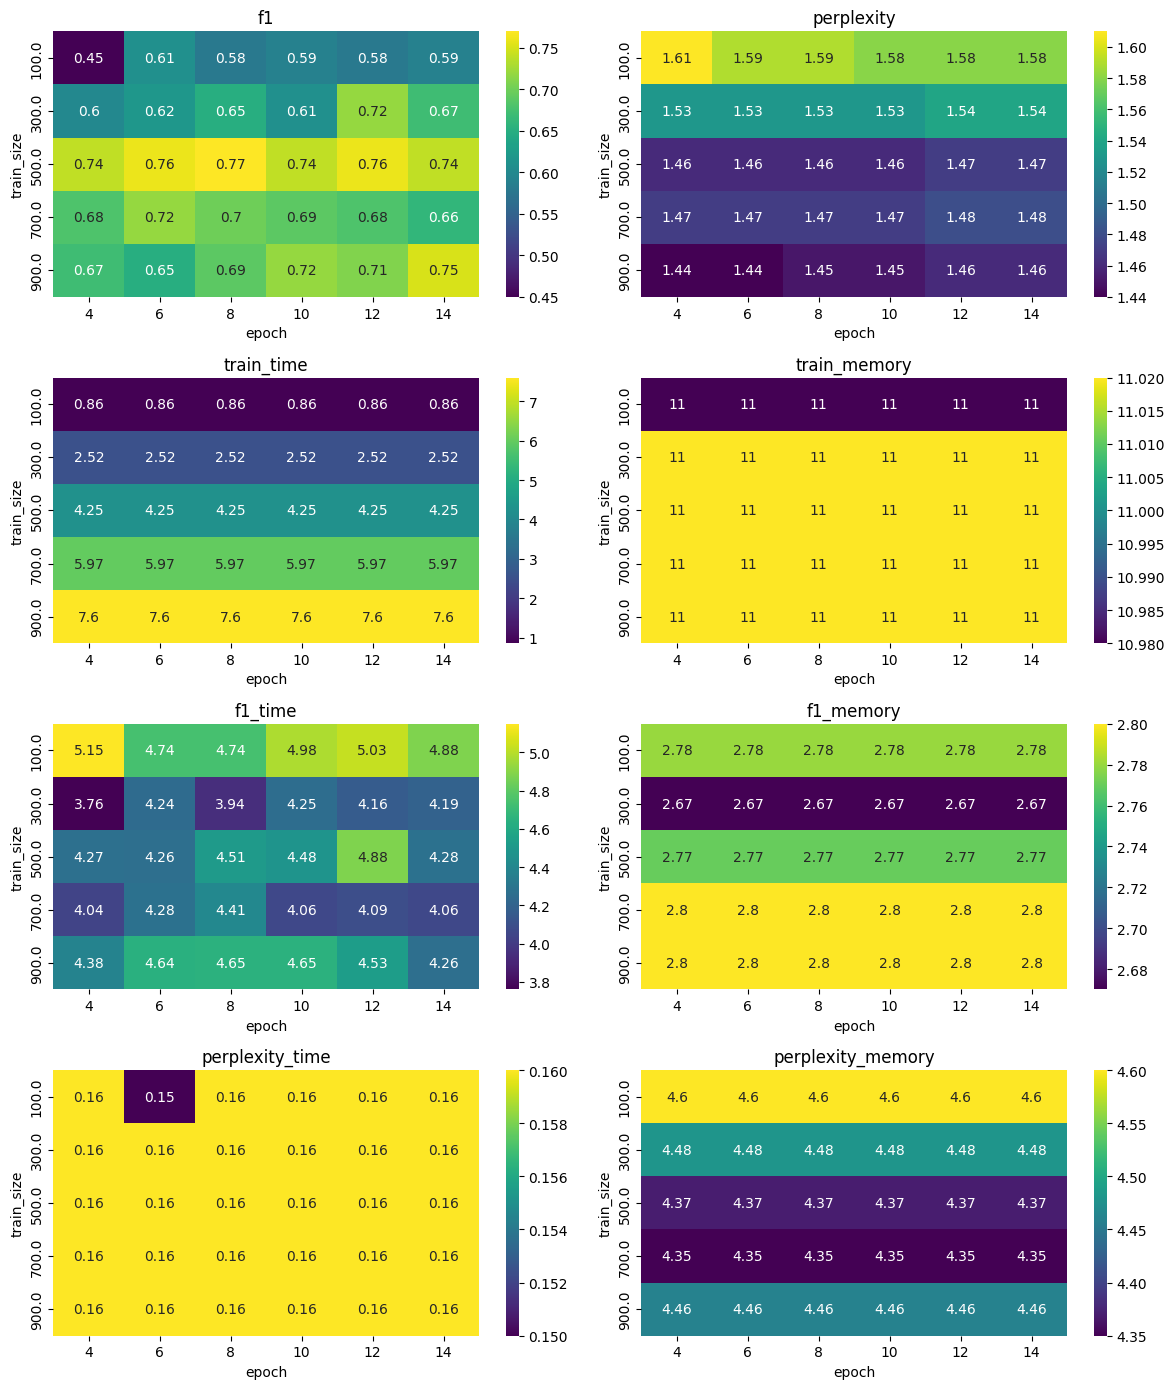

In [ ]:

# 3. Все метрики в одном цикле
metrics = ['f1', 'perplexity', 'train_time', 'train_memory',
           'f1_time', 'f1_memory', 'perplexity_time', 'perplexity_memory']

fig, axes = plt.subplots(4, 2, figsize=(12, 14))
axes = axes.flatten()
for ax, metric in zip(axes, metrics):
    pivot = df_long.pivot(index='train_size', columns='epoch', values=metric)
    sns.heatmap(pivot, annot=True, fmt='.3g', cmap='viridis', ax=ax)
    ax.set_title(metric)
    ax.set_xlabel('epoch')
    ax.set_ylabel('train_size')
plt.tight_layout()
plt.show()

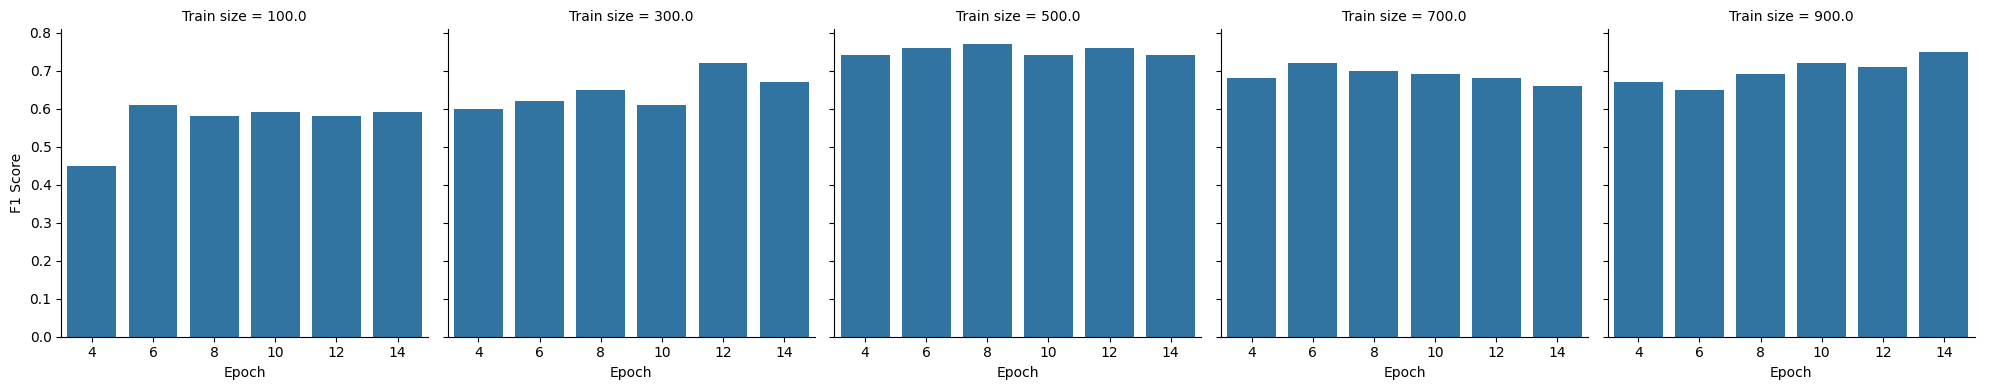

In [ ]:
g = sns.catplot(data=df_long, x='epoch', y='f1', col='train_size',
                kind='bar', height=4, aspect=1)
g.set_axis_labels("Epoch", "F1 Score")
g.set_titles("Train size = {col_name}")
plt.show()

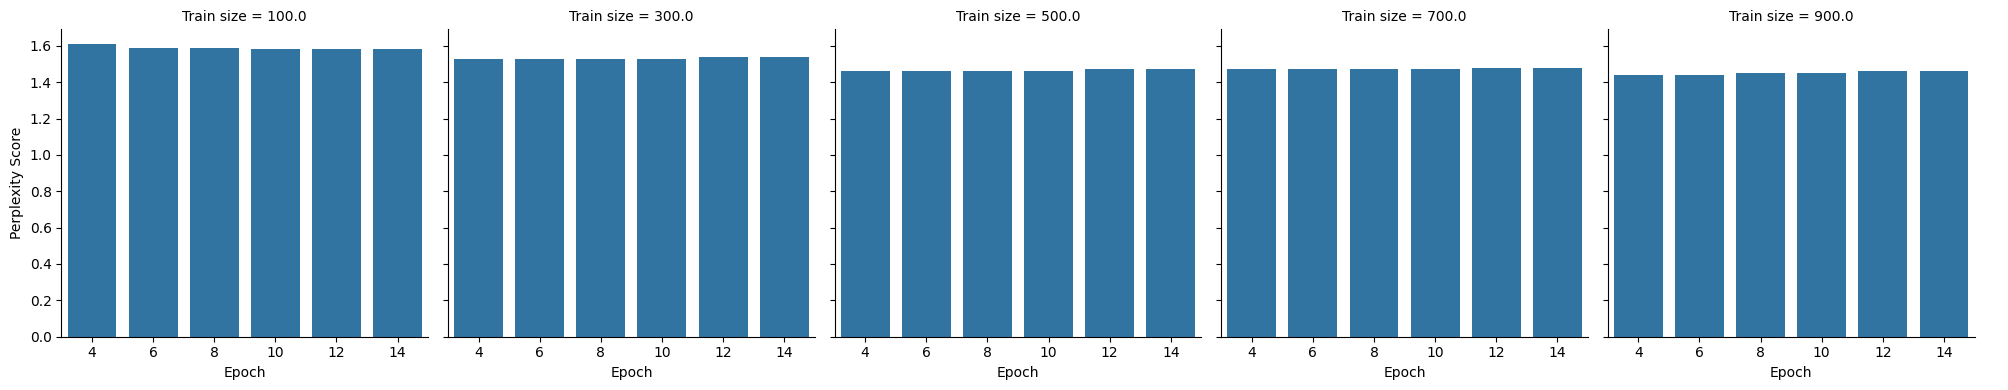

In [ ]:
g = sns.catplot(data=df_long, x='epoch', y='perplexity', col='train_size',
                kind='bar', height=4, aspect=1)
g.set_axis_labels("Epoch", "Perplexity Score")
g.set_titles("Train size = {col_name}")
plt.show()

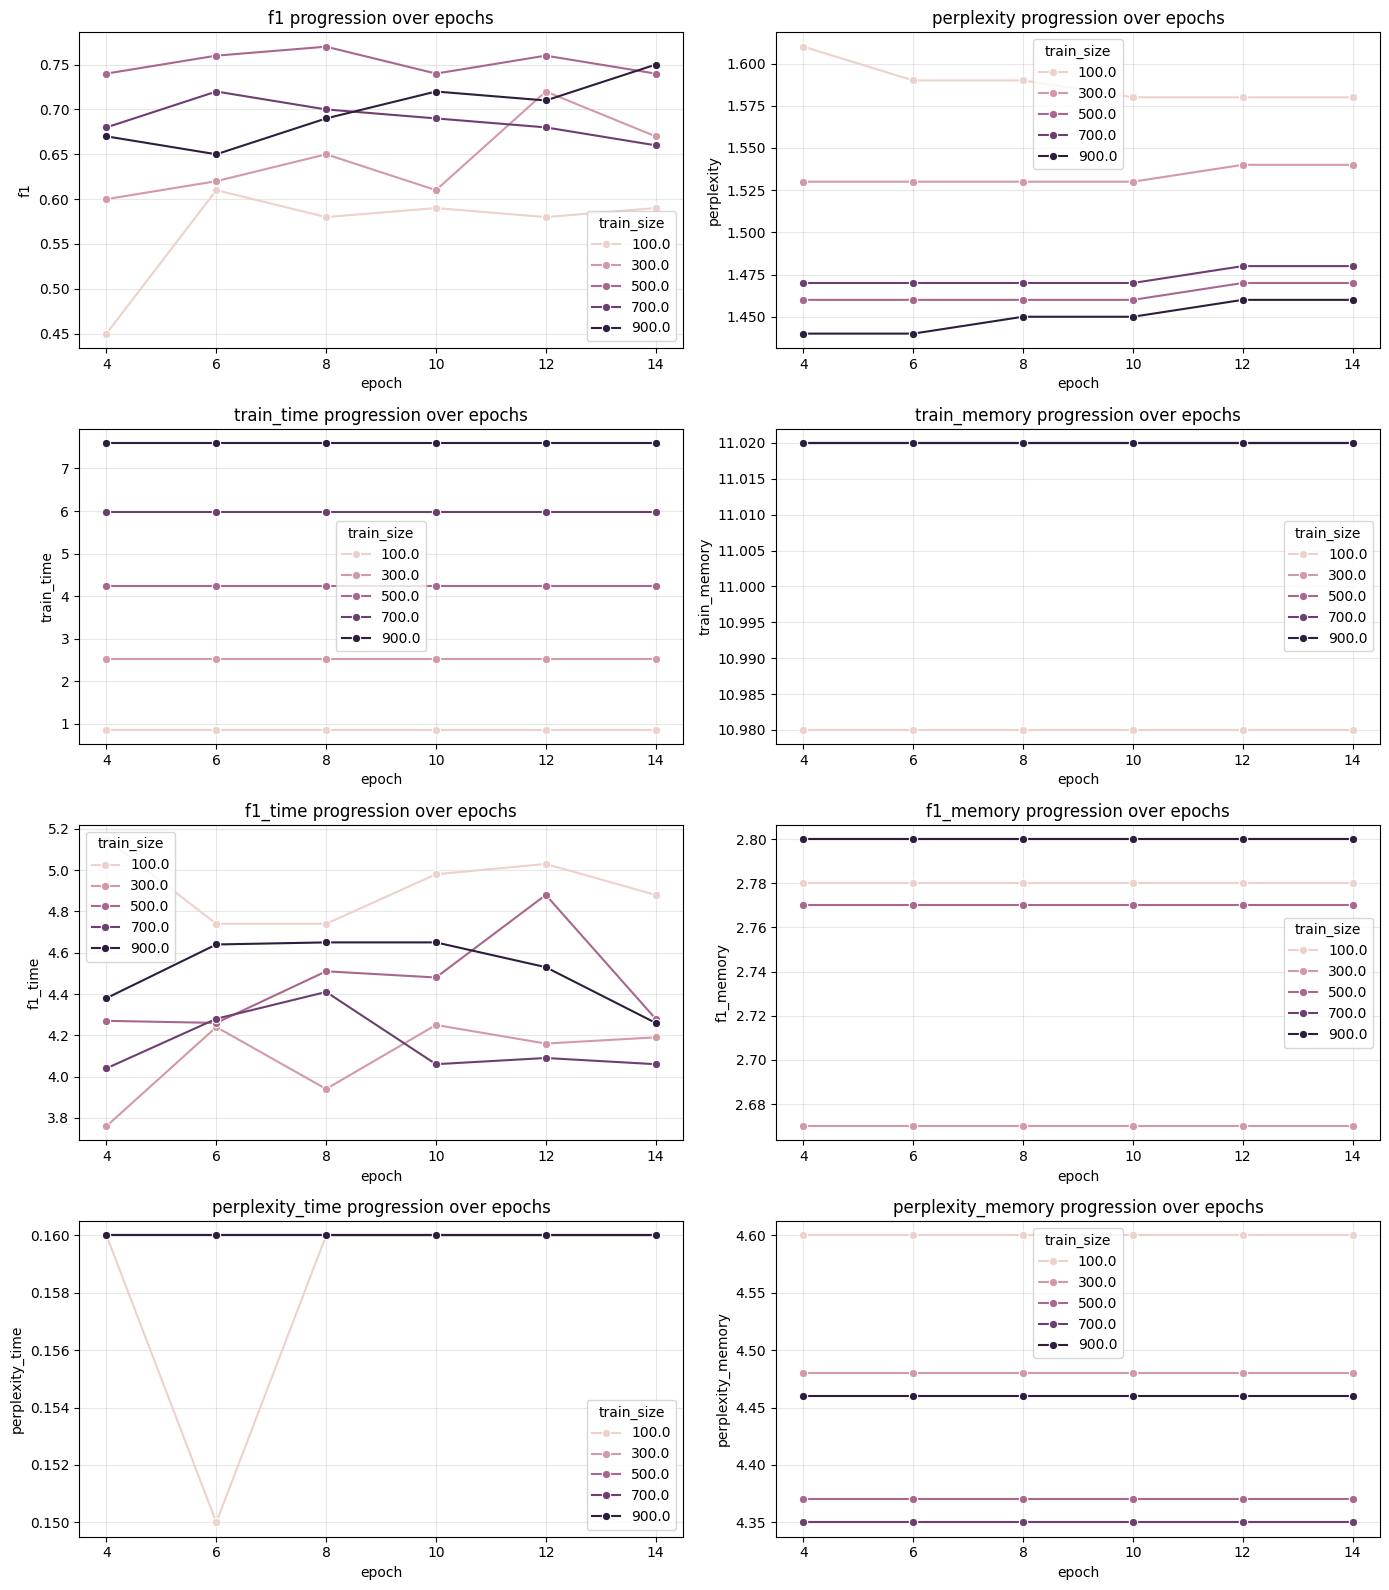

In [ ]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 16))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    ax = axes[i]
    sns.lineplot(data=df_long, x='epoch', y=metric, hue='train_size',
                 marker='o', ax=ax)
    ax.set_title(f'{metric} progression over epochs')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# lora 0.8



In [18]:
df_all = load_all_results("/content/drive/MyDrive/rag_experiments_second_oracle", "results_train_*_lora_config_oracle.csv")
print(df_all)

   train_size  trainable_params_m  before_train_peak_memory_gb  \
0         100            8.798208                         2.39   
1         300            8.798208                         2.39   
2         500            8.798208                         2.39   
3         700            8.798208                         2.39   

   train_time_min  train_peak_memory_gb    f1  evaluate_f1_time_min  \
0            0.90                 10.90  0.49                  4.83   
1            2.58                 10.93  0.58                  4.05   
2            4.27                 10.93  0.62                  4.88   
3            5.94                 10.93  0.60                  4.17   

   evaluate_f1_peak_memory_gb  perplexity  evaluate_perplexity_time_min  ...  \
0                        2.63        1.72                          0.16  ...   
1                        2.66        1.68                          0.16  ...   
2                        2.60        1.68                          0.16  

In [19]:

# 1. Вручную соберём длинный формат
records = []
for _, row in df_all.iterrows():
    train_size = row['train_size']
    for ep in [4, 6, 8, 10, 12, 14]:
        records.append({
            'train_size': train_size,
            'epoch': ep,
            'f1': row[f'f1_epoch{ep}'],
            'perplexity': row[f'perplexity_epoch{ep}'],
            'f1_time': row[f'f1_time_epoch{ep}'],
            'f1_memory': row[f'f1_memory_epoch{ep}'],
            'perplexity_time': row[f'perplexity_time_epoch{ep}'],
            'perplexity_memory': row[f'perplexity_memory_epoch{ep}'],
            'train_time': row['train_time_min'],
            'train_memory': row['train_peak_memory_gb']
        })

df_long = pd.DataFrame(records)


In [20]:
df_long

,train_size,epoch,f1,perplexity,f1_time,f1_memory,perplexity_time,perplexity_memory,train_time,train_memory
0,100.0,4,0.54,1.75,4.40,2.63,0.16,4.36,0.90,10.90
1,100.0,6,0.54,1.73,4.26,2.63,0.16,4.36,0.90,10.90
2,100.0,8,0.54,1.73,4.13,2.63,0.16,4.36,0.90,10.90
3,100.0,10,0.54,1.72,4.40,2.63,0.16,4.36,0.90,10.90
4,100.0,12,0.50,1.72,4.35,2.63,0.16,4.36,0.90,10.90
5,100.0,14,0.49,1.72,4.83,2.63,0.16,4.36,0.90,10.90
6,300.0,4,0.51,1.68,4.65,2.66,0.16,4.25,2.58,10.93
7,300.0,6,0.55,1.67,4.45,2.66,0.16,4.25,2.58,10.93
8,300.0,8,0.56,1.67,4.51,2.66,0.16,4.25,2.58,10.93
9,300.0,10,0.54,1.68,5.36,2.66,0.16,4.25,2.58,10.93


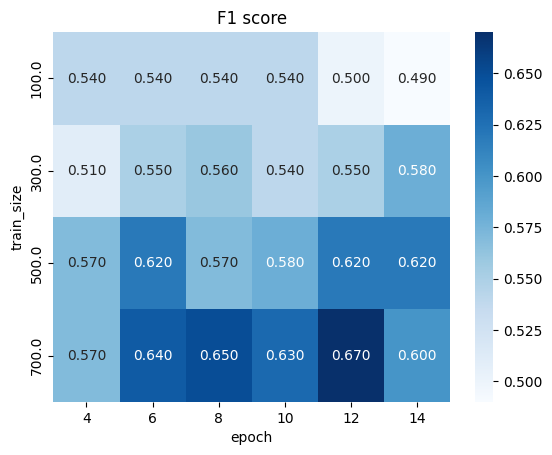

In [21]:

# 2. Heatmap (пример для f1)
pivot_f1 = df_long.pivot(index='train_size', columns='epoch', values='f1')
sns.heatmap(pivot_f1, annot=True, fmt='.3f', cmap='Blues')
plt.title('F1 score')
plt.show()


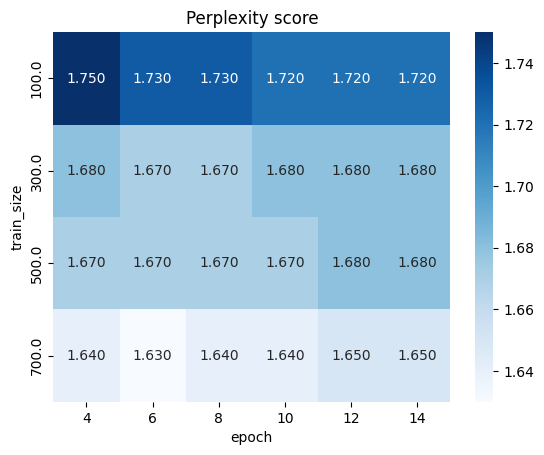

In [22]:

# 2. Heatmap (пример для Perplexity)
pivot_per = df_long.pivot(index='train_size', columns='epoch', values='perplexity')
sns.heatmap(pivot_per, annot=True, fmt='.3f', cmap='Blues')
plt.title('Perplexity score')
plt.show()


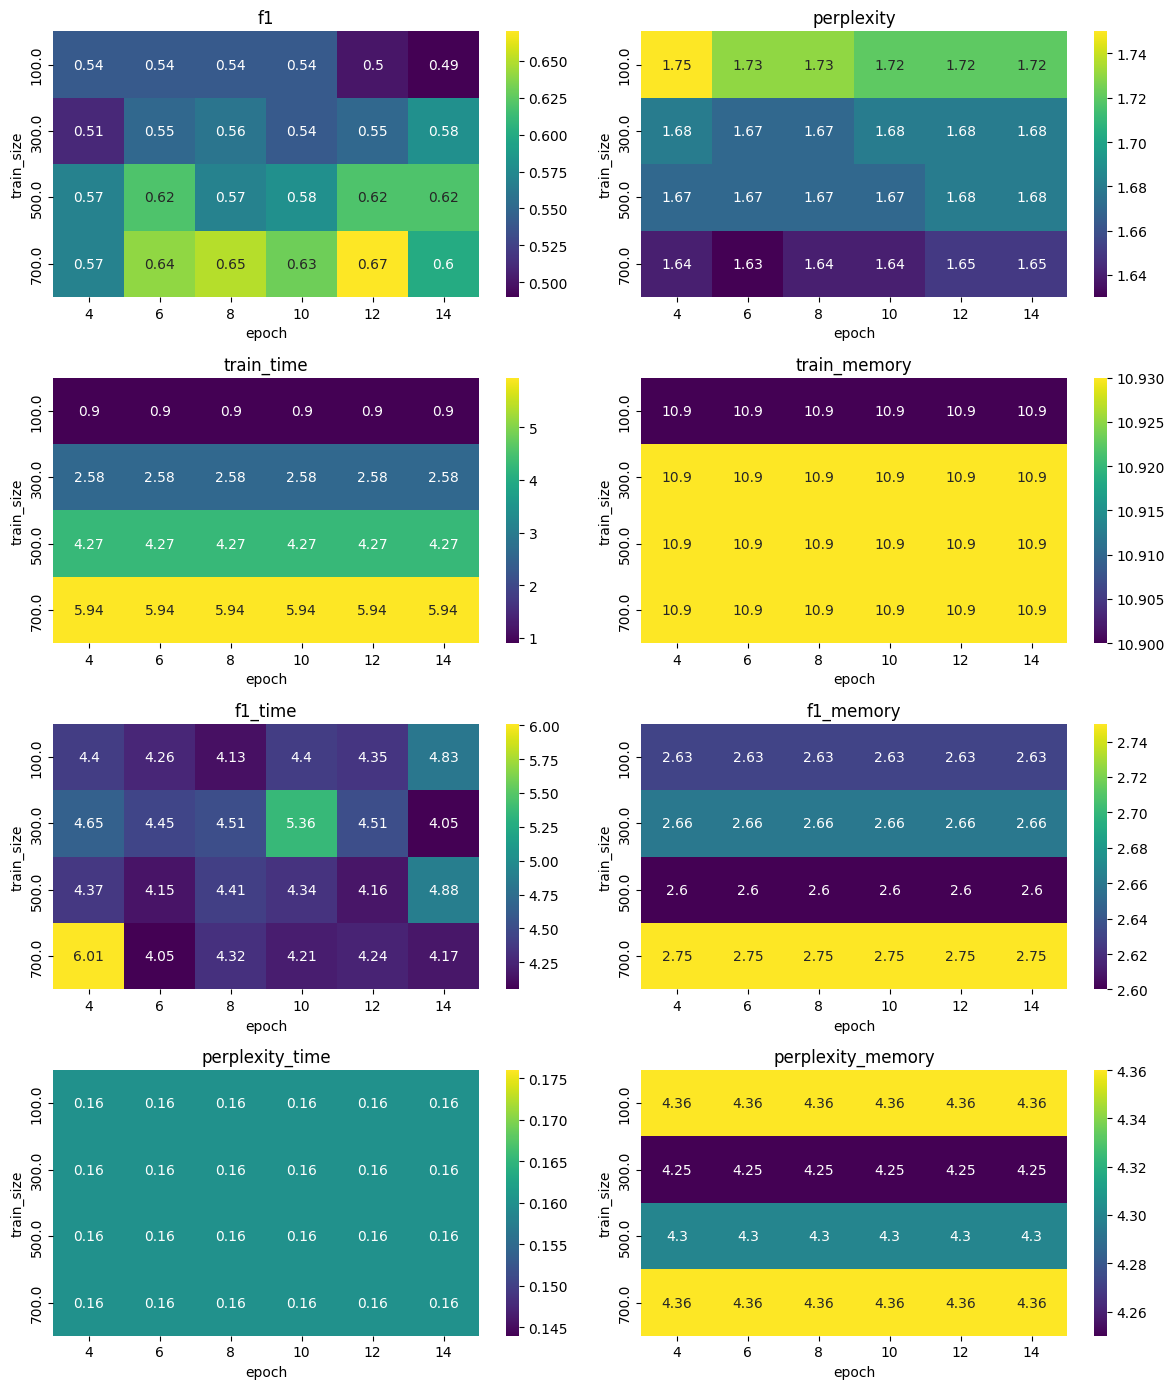

In [23]:

# 3. Все метрики в одном цикле
metrics = ['f1', 'perplexity', 'train_time', 'train_memory',
           'f1_time', 'f1_memory', 'perplexity_time', 'perplexity_memory']

fig, axes = plt.subplots(4, 2, figsize=(12, 14))
axes = axes.flatten()
for ax, metric in zip(axes, metrics):
    pivot = df_long.pivot(index='train_size', columns='epoch', values=metric)
    sns.heatmap(pivot, annot=True, fmt='.3g', cmap='viridis', ax=ax)
    ax.set_title(metric)
    ax.set_xlabel('epoch')
    ax.set_ylabel('train_size')
plt.tight_layout()
plt.show()

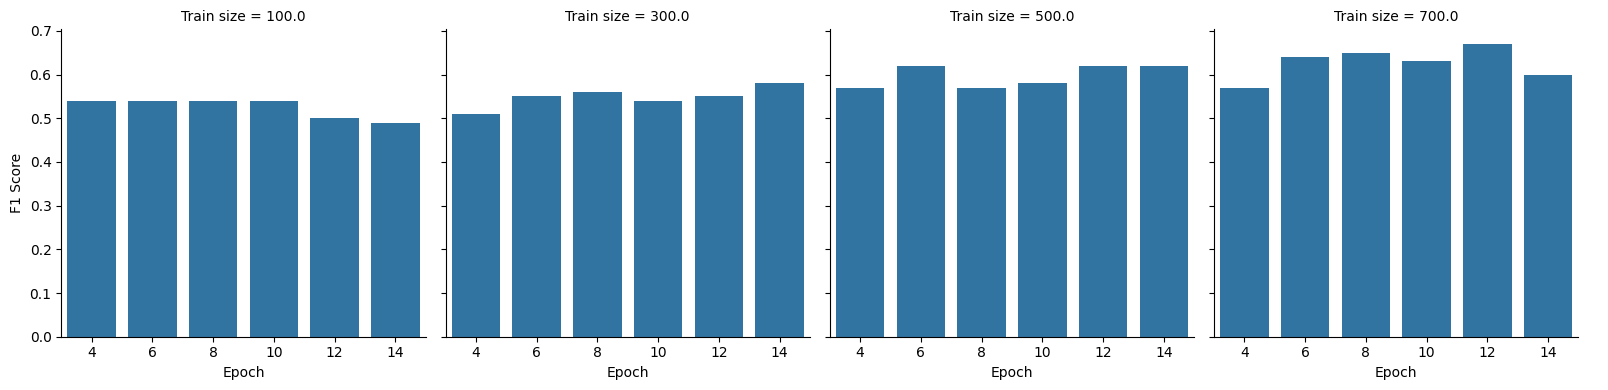

In [24]:
g = sns.catplot(data=df_long, x='epoch', y='f1', col='train_size',
                kind='bar', height=4, aspect=1)
g.set_axis_labels("Epoch", "F1 Score")
g.set_titles("Train size = {col_name}")
plt.show()

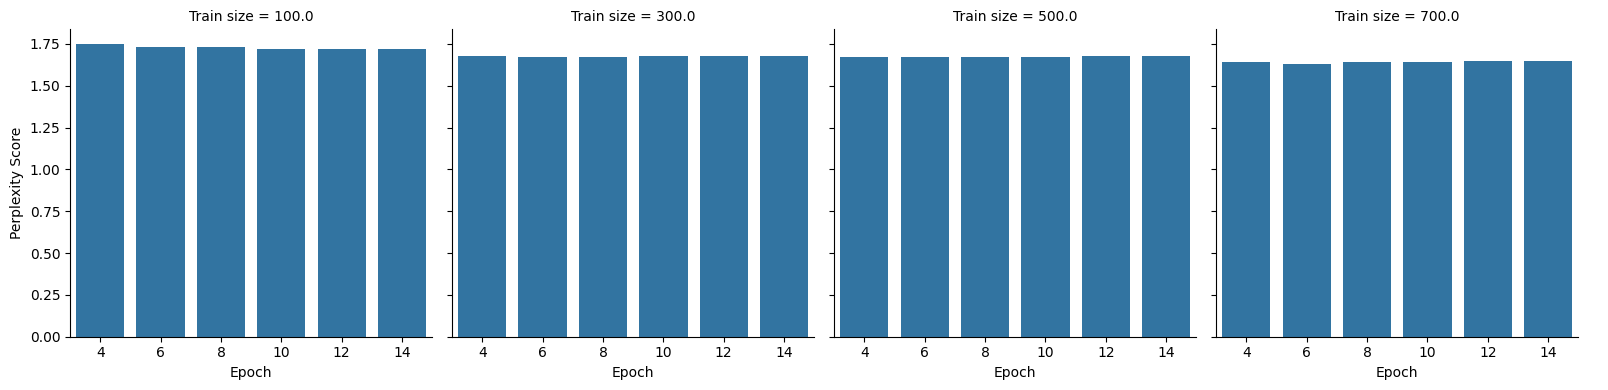

In [25]:
g = sns.catplot(data=df_long, x='epoch', y='perplexity', col='train_size',
                kind='bar', height=4, aspect=1)
g.set_axis_labels("Epoch", "Perplexity Score")
g.set_titles("Train size = {col_name}")
plt.show()

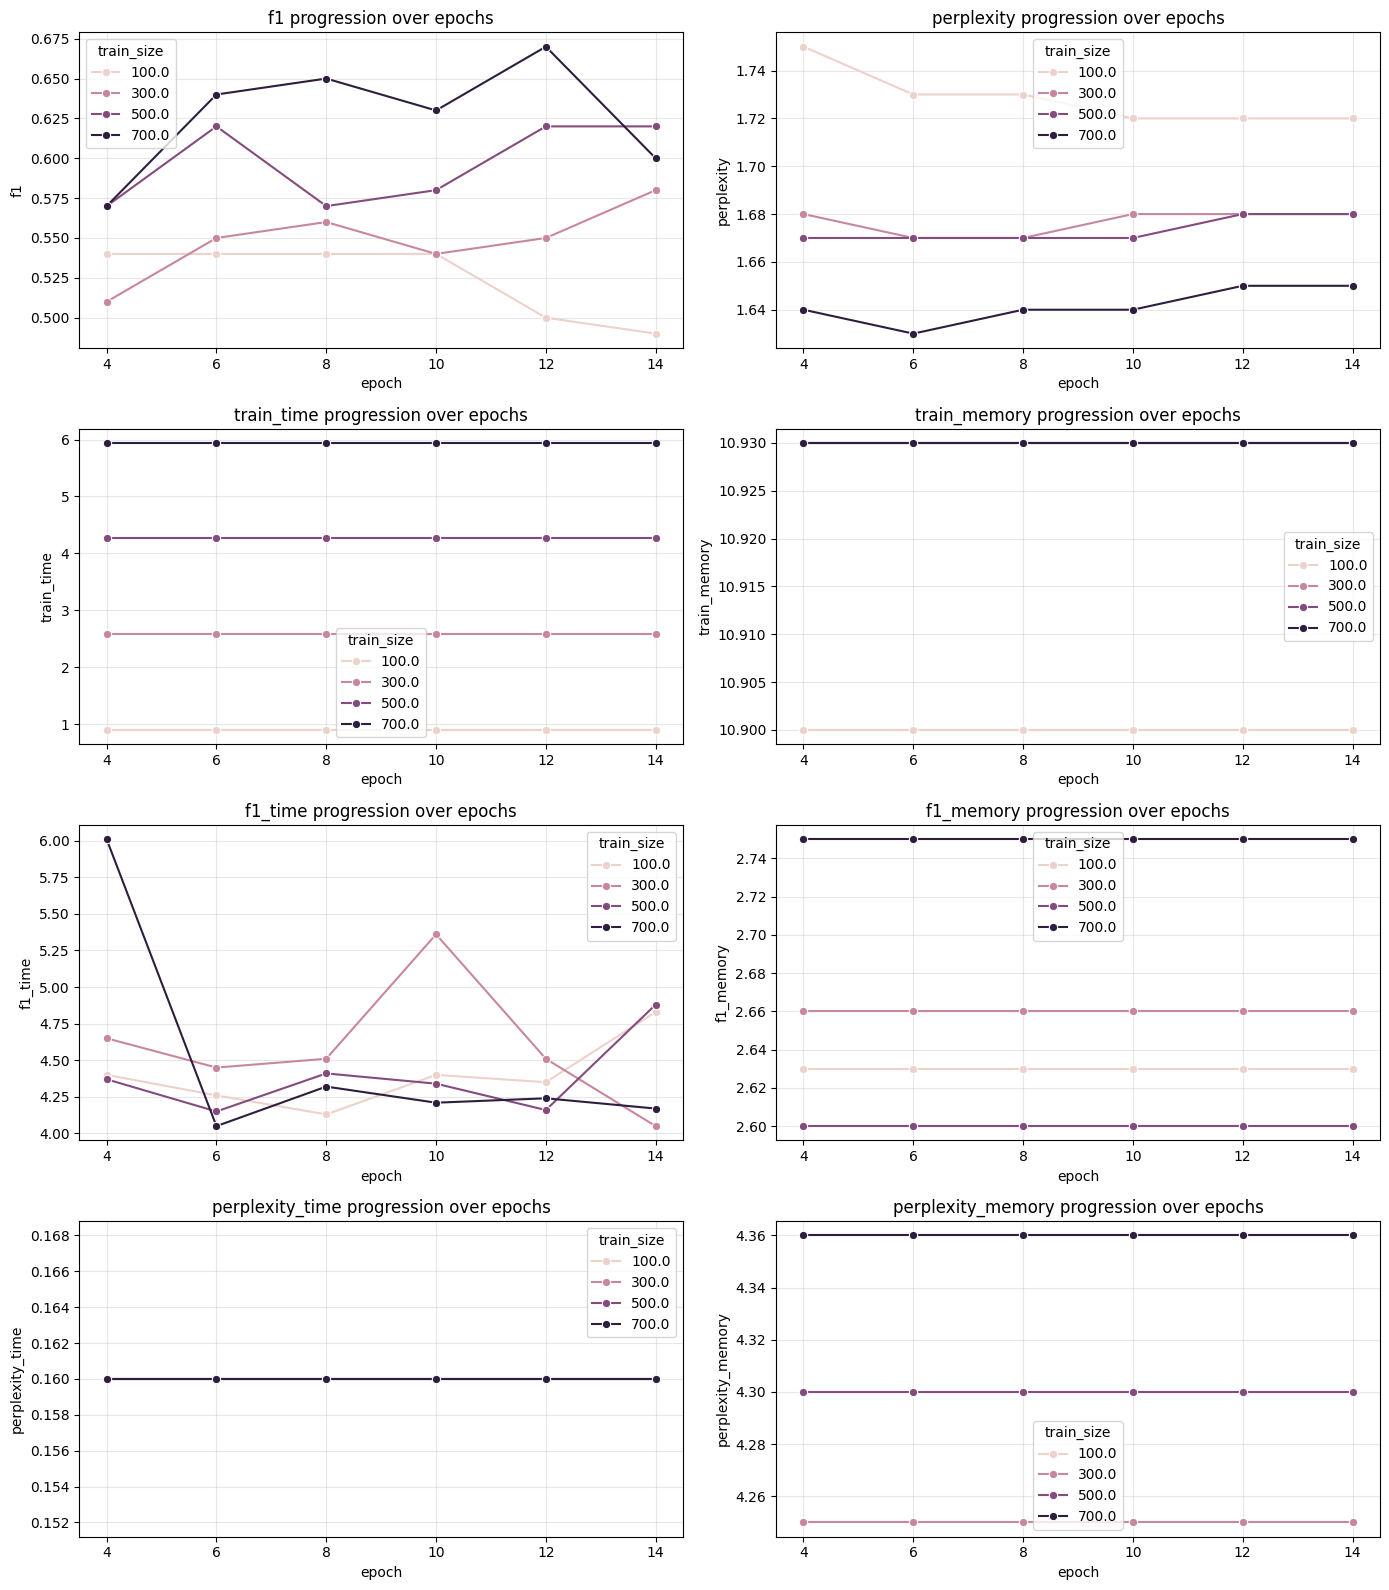

In [26]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 16))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    ax = axes[i]
    sns.lineplot(data=df_long, x='epoch', y=metric, hue='train_size',
                 marker='o', ax=ax)
    ax.set_title(f'{metric} progression over epochs')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ia3 gold


In [27]:
df_all = load_all_results("/content/drive/MyDrive/rag_experiments_second", "results_train_*_ia3_config.csv")
print(df_all)

   train_size  trainable_params_m  before_train_peak_memory_gb  \
0         100             0.12288                         6.10   
1         300             0.12288                         2.47   
2         500             0.12288                         2.47   
3         700             0.12288                         2.47   
4         900             0.12288                         2.47   
5        1100             0.12288                         2.47   

   train_time_min  train_peak_memory_gb   f1  evaluate_f1_time_min  \
0            0.68                 10.89  0.0                  1.52   
1            1.98                 10.89  0.0                  1.47   
2            3.33                 10.89  0.0                  1.76   
3            4.68                 10.89  0.0                  1.91   
4            5.97                 10.89  0.0                  2.64   
5            7.32                 10.89  0.0                  3.61   

   evaluate_f1_peak_memory_gb  perplexity  eva

In [28]:

# 1. Вручную соберём длинный формат
records = []
for _, row in df_all.iterrows():
    train_size = row['train_size']
    for ep in [4, 6, 8, 10, 12, 14]:
        records.append({
            'train_size': train_size,
            'epoch': ep,
            'f1': row[f'f1_epoch{ep}'],
            'perplexity': row[f'perplexity_epoch{ep}'],
            'f1_time': row[f'f1_time_epoch{ep}'],
            'f1_memory': row[f'f1_memory_epoch{ep}'],
            'perplexity_time': row[f'perplexity_time_epoch{ep}'],
            'perplexity_memory': row[f'perplexity_memory_epoch{ep}'],
            'train_time': row['train_time_min'],
            'train_memory': row['train_peak_memory_gb']
        })

df_long = pd.DataFrame(records)


In [29]:
df_long

,train_size,epoch,f1,perplexity,f1_time,f1_memory,perplexity_time,perplexity_memory,train_time,train_memory
0,100.0,4,0.0,3.00,1.54,2.65,0.1,4.48,0.68,10.89
1,100.0,6,0.0,3.00,1.54,2.65,0.1,4.48,0.68,10.89
2,100.0,8,0.0,3.00,1.53,2.65,0.1,4.48,0.68,10.89
3,100.0,10,0.0,3.00,1.54,2.65,0.1,4.48,0.68,10.89
4,100.0,12,0.0,3.00,1.54,2.65,0.1,4.48,0.68,10.89
5,100.0,14,0.0,3.00,1.52,2.65,0.1,4.48,0.68,10.89
6,300.0,4,0.0,2.87,1.52,2.55,0.1,4.36,1.98,10.89
7,300.0,6,0.0,2.79,1.49,2.55,0.1,4.36,1.98,10.89
8,300.0,8,0.0,2.76,1.43,2.55,0.1,4.36,1.98,10.89
9,300.0,10,0.0,2.75,1.41,2.55,0.1,4.36,1.98,10.89


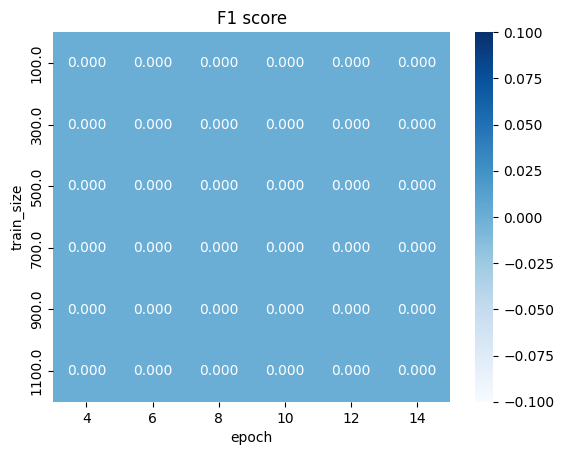

In [30]:

# 2. Heatmap (пример для f1)
pivot_f1 = df_long.pivot(index='train_size', columns='epoch', values='f1')
sns.heatmap(pivot_f1, annot=True, fmt='.3f', cmap='Blues')
plt.title('F1 score')
plt.show()


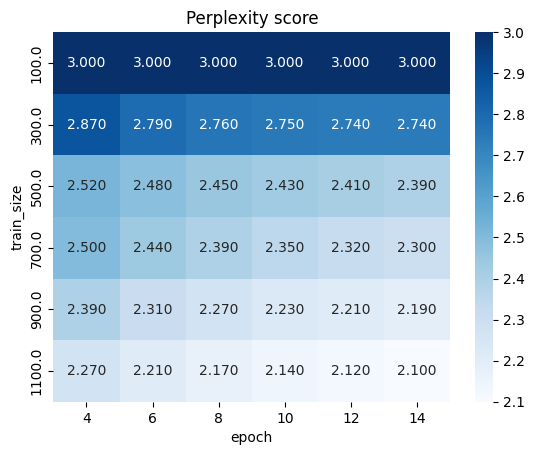

In [31]:

# 2. Heatmap (пример для Perplexity)
pivot_per = df_long.pivot(index='train_size', columns='epoch', values='perplexity')
sns.heatmap(pivot_per, annot=True, fmt='.3f', cmap='Blues')
plt.title('Perplexity score')
plt.show()


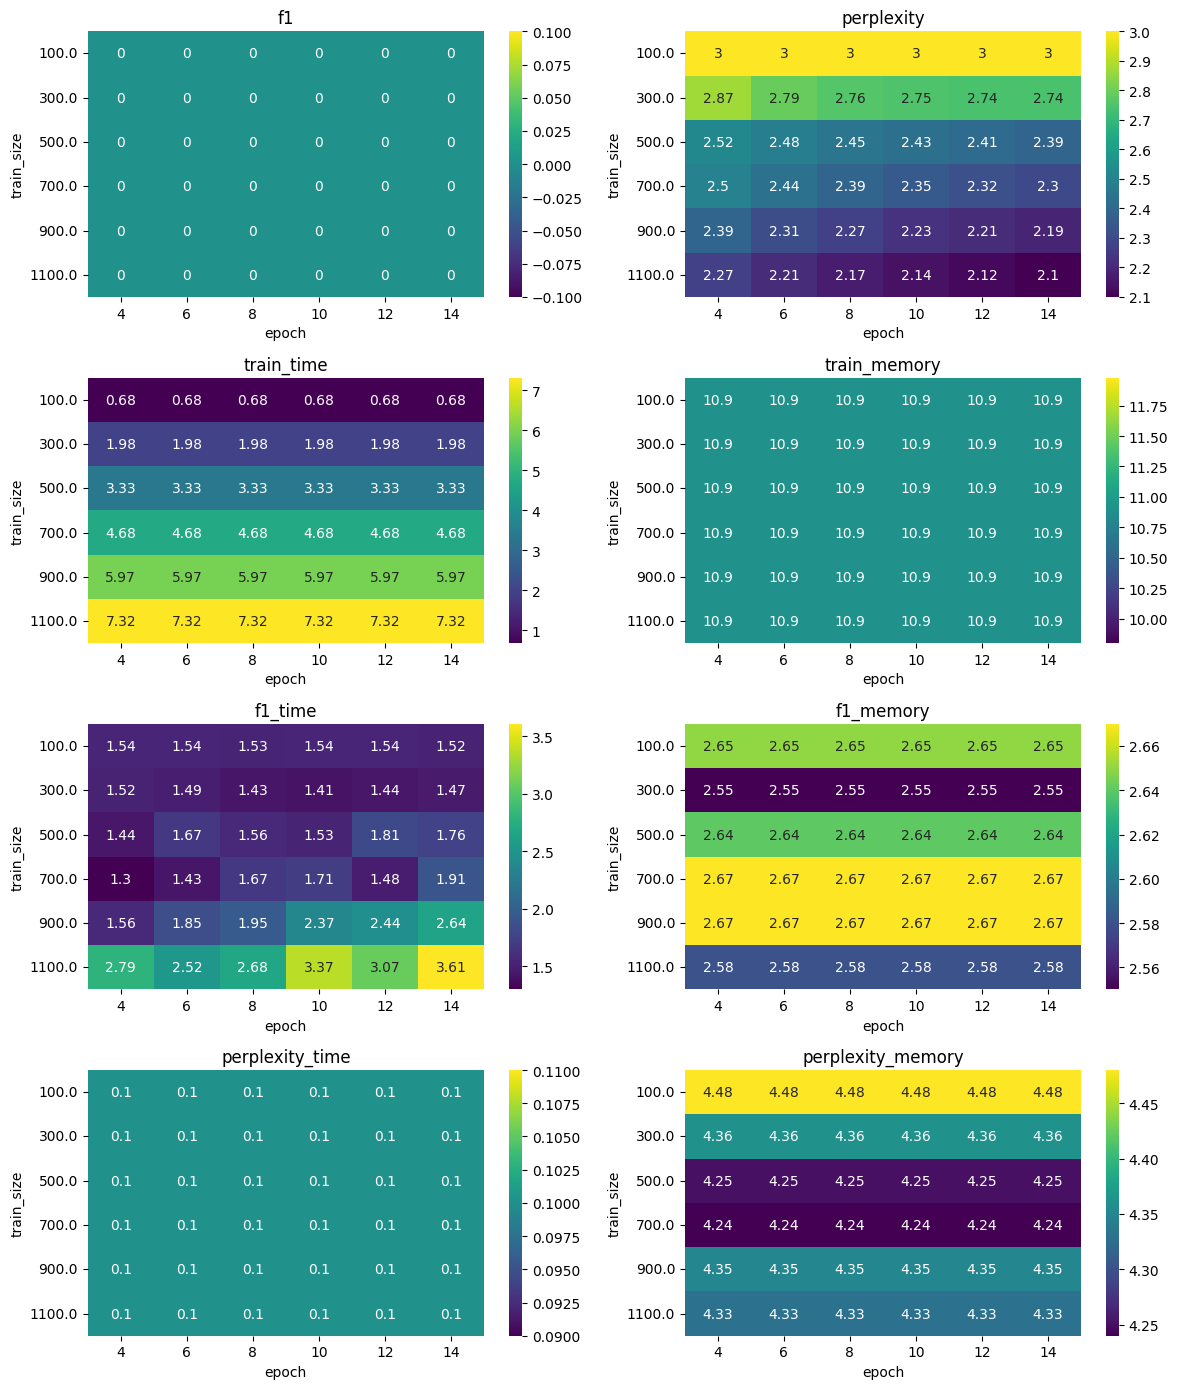

In [32]:

# 3. Все метрики в одном цикле
metrics = ['f1', 'perplexity', 'train_time', 'train_memory',
           'f1_time', 'f1_memory', 'perplexity_time', 'perplexity_memory']

fig, axes = plt.subplots(4, 2, figsize=(12, 14))
axes = axes.flatten()
for ax, metric in zip(axes, metrics):
    pivot = df_long.pivot(index='train_size', columns='epoch', values=metric)
    sns.heatmap(pivot, annot=True, fmt='.3g', cmap='viridis', ax=ax)
    ax.set_title(metric)
    ax.set_xlabel('epoch')
    ax.set_ylabel('train_size')
plt.tight_layout()
plt.show()

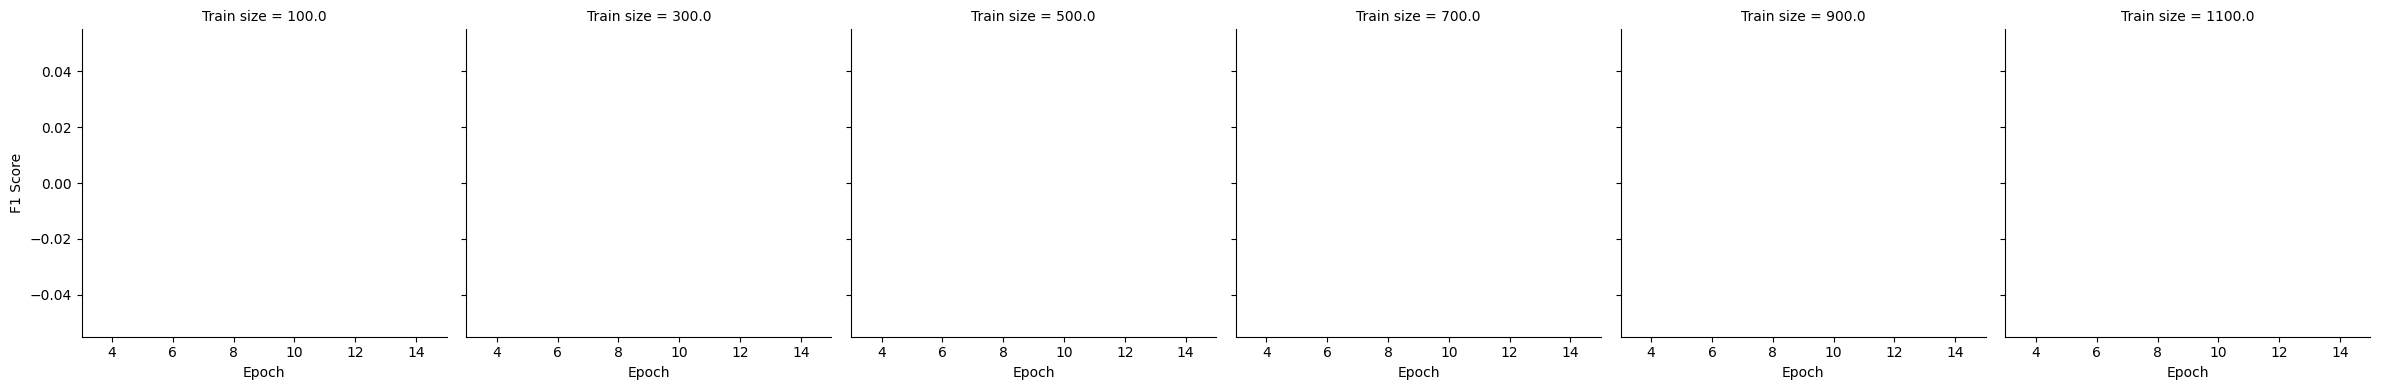

In [33]:
g = sns.catplot(data=df_long, x='epoch', y='f1', col='train_size',
                kind='bar', height=4, aspect=1)
g.set_axis_labels("Epoch", "F1 Score")
g.set_titles("Train size = {col_name}")
plt.show()

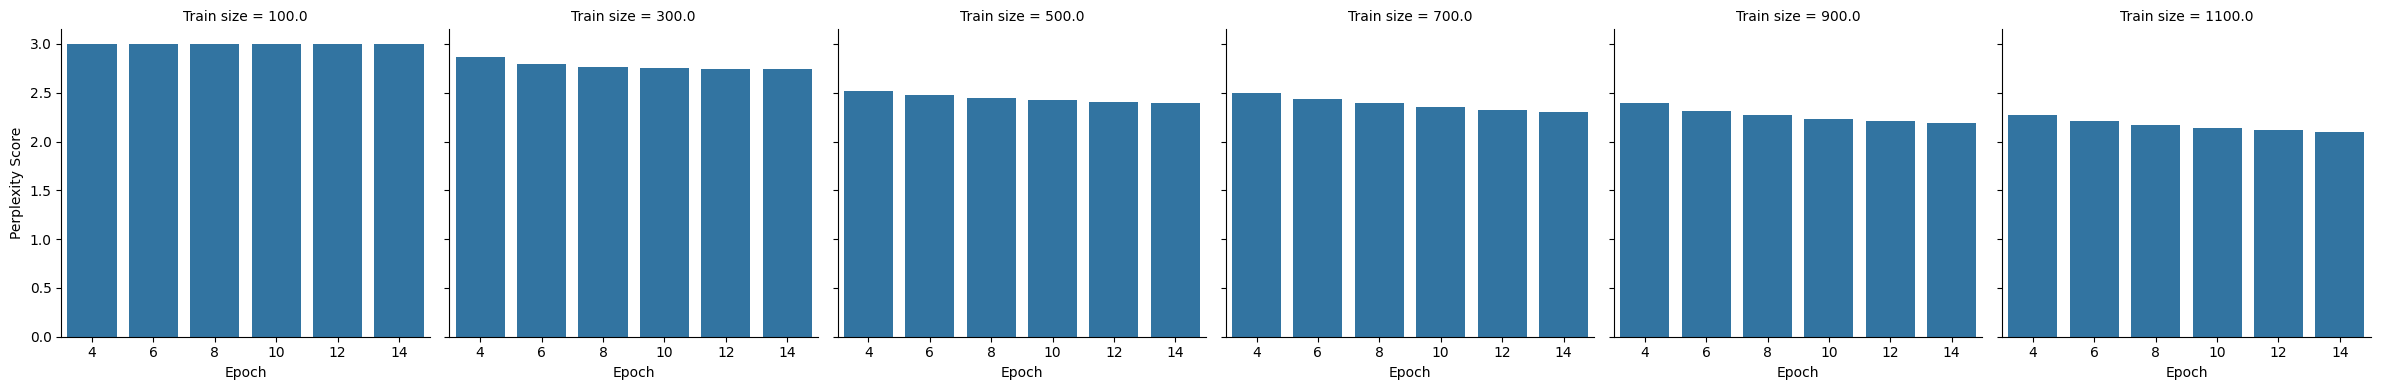

In [34]:
g = sns.catplot(data=df_long, x='epoch', y='perplexity', col='train_size',
                kind='bar', height=4, aspect=1)
g.set_axis_labels("Epoch", "Perplexity Score")
g.set_titles("Train size = {col_name}")
plt.show()

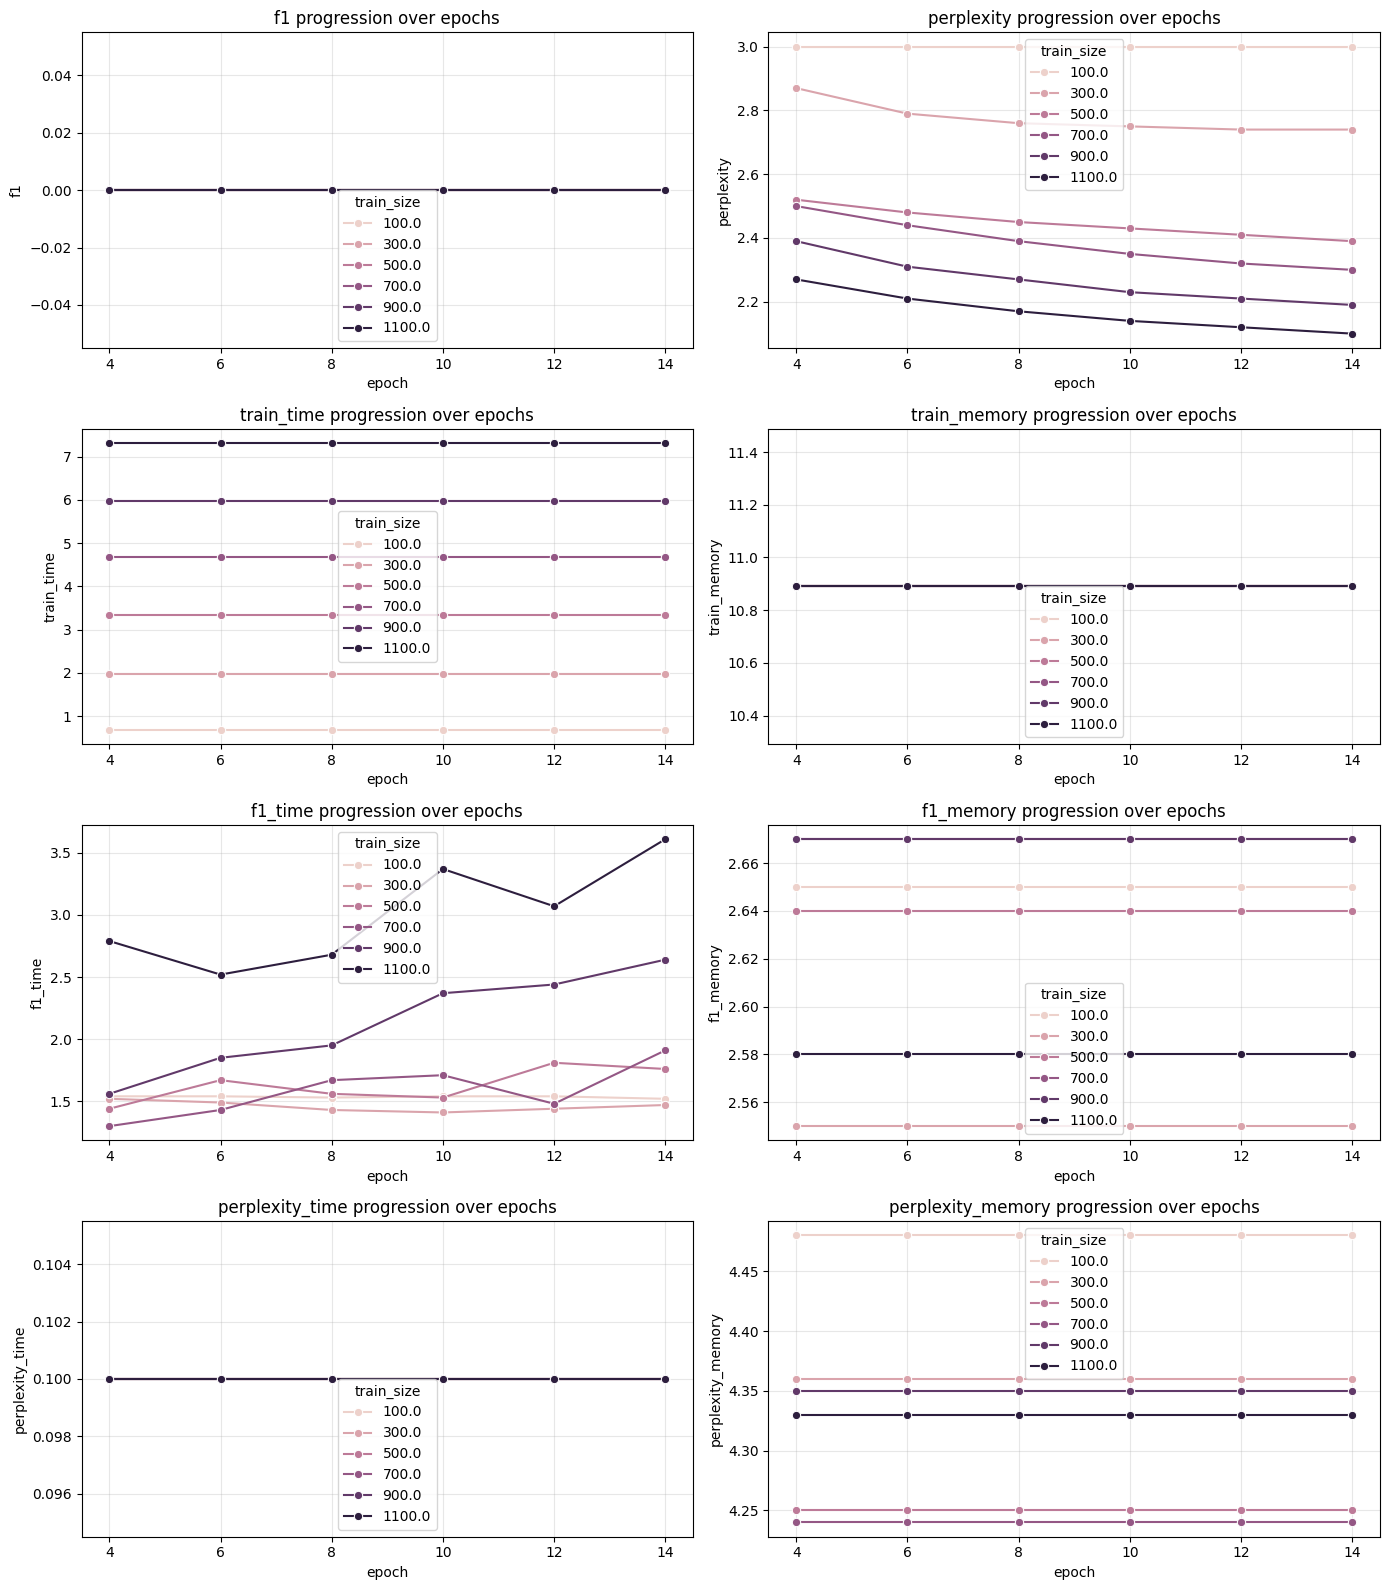

In [35]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 16))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    ax = axes[i]
    sns.lineplot(data=df_long, x='epoch', y=metric, hue='train_size',
                 marker='o', ax=ax)
    ax.set_title(f'{metric} progression over epochs')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# lora gold


In [36]:
df_all = load_all_results("/content/drive/MyDrive/rag_experiments_second_oracle", "results_train_*_ia3_config_oracle.csv")
print(df_all)

   train_size  trainable_params_m  before_train_peak_memory_gb  \
0         100             0.12288                         2.39   
1         300             0.12288                         2.39   
2         500             0.12288                         2.39   
3         700             0.12288                         2.39   

   train_time_min  train_peak_memory_gb   f1  evaluate_f1_time_min  \
0            0.70                  10.8  0.0                  1.74   
1            2.02                  10.8  0.0                  1.67   
2            3.34                  10.8  0.0                  1.68   
3            4.66                  10.8  0.0                  2.70   

   evaluate_f1_peak_memory_gb  perplexity  evaluate_perplexity_time_min  ...  \
0                        2.50        3.29                           0.1  ...   
1                        2.53        2.93                           0.1  ...   
2                        2.47        2.75                           0.1  ...  

In [37]:

# 1. Вручную соберём длинный формат
records = []
for _, row in df_all.iterrows():
    train_size = row['train_size']
    for ep in [4, 6, 8, 10, 12, 14]:
        records.append({
            'train_size': train_size,
            'epoch': ep,
            'f1': row[f'f1_epoch{ep}'],
            'perplexity': row[f'perplexity_epoch{ep}'],
            'f1_time': row[f'f1_time_epoch{ep}'],
            'f1_memory': row[f'f1_memory_epoch{ep}'],
            'perplexity_time': row[f'perplexity_time_epoch{ep}'],
            'perplexity_memory': row[f'perplexity_memory_epoch{ep}'],
            'train_time': row['train_time_min'],
            'train_memory': row['train_peak_memory_gb']
        })

df_long = pd.DataFrame(records)


In [38]:
df_long

,train_size,epoch,f1,perplexity,f1_time,f1_memory,perplexity_time,perplexity_memory,train_time,train_memory
0,100.0,4,0.0,3.29,1.82,2.50,0.1,4.24,0.70,10.8
1,100.0,6,0.0,3.29,1.83,2.50,0.1,4.24,0.70,10.8
2,100.0,8,0.0,3.29,1.83,2.50,0.1,4.24,0.70,10.8
3,100.0,10,0.0,3.29,1.84,2.50,0.1,4.24,0.70,10.8
4,100.0,12,0.0,3.29,1.83,2.50,0.1,4.24,0.70,10.8
5,100.0,14,0.0,3.29,1.74,2.50,0.1,4.24,0.70,10.8
6,300.0,4,0.0,3.07,1.83,2.53,0.1,4.14,2.02,10.8
7,300.0,6,0.0,2.98,1.72,2.53,0.1,4.14,2.02,10.8
8,300.0,8,0.0,2.96,1.73,2.53,0.1,4.14,2.02,10.8
9,300.0,10,0.0,2.94,1.54,2.53,0.1,4.14,2.02,10.8


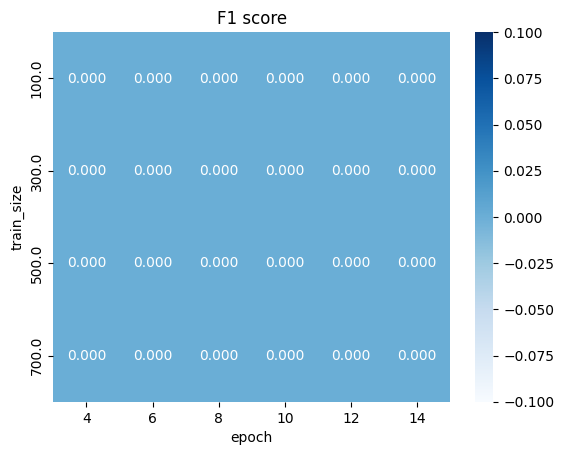

In [39]:

# 2. Heatmap (пример для f1)
pivot_f1 = df_long.pivot(index='train_size', columns='epoch', values='f1')
sns.heatmap(pivot_f1, annot=True, fmt='.3f', cmap='Blues')
plt.title('F1 score')
plt.show()


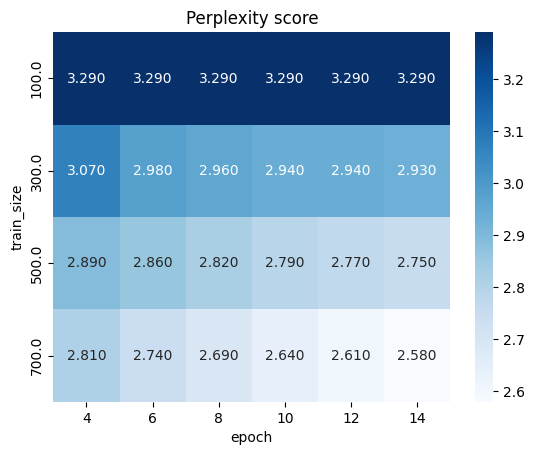

In [40]:

# 2. Heatmap (пример для Perplexity)
pivot_per = df_long.pivot(index='train_size', columns='epoch', values='perplexity')
sns.heatmap(pivot_per, annot=True, fmt='.3f', cmap='Blues')
plt.title('Perplexity score')
plt.show()


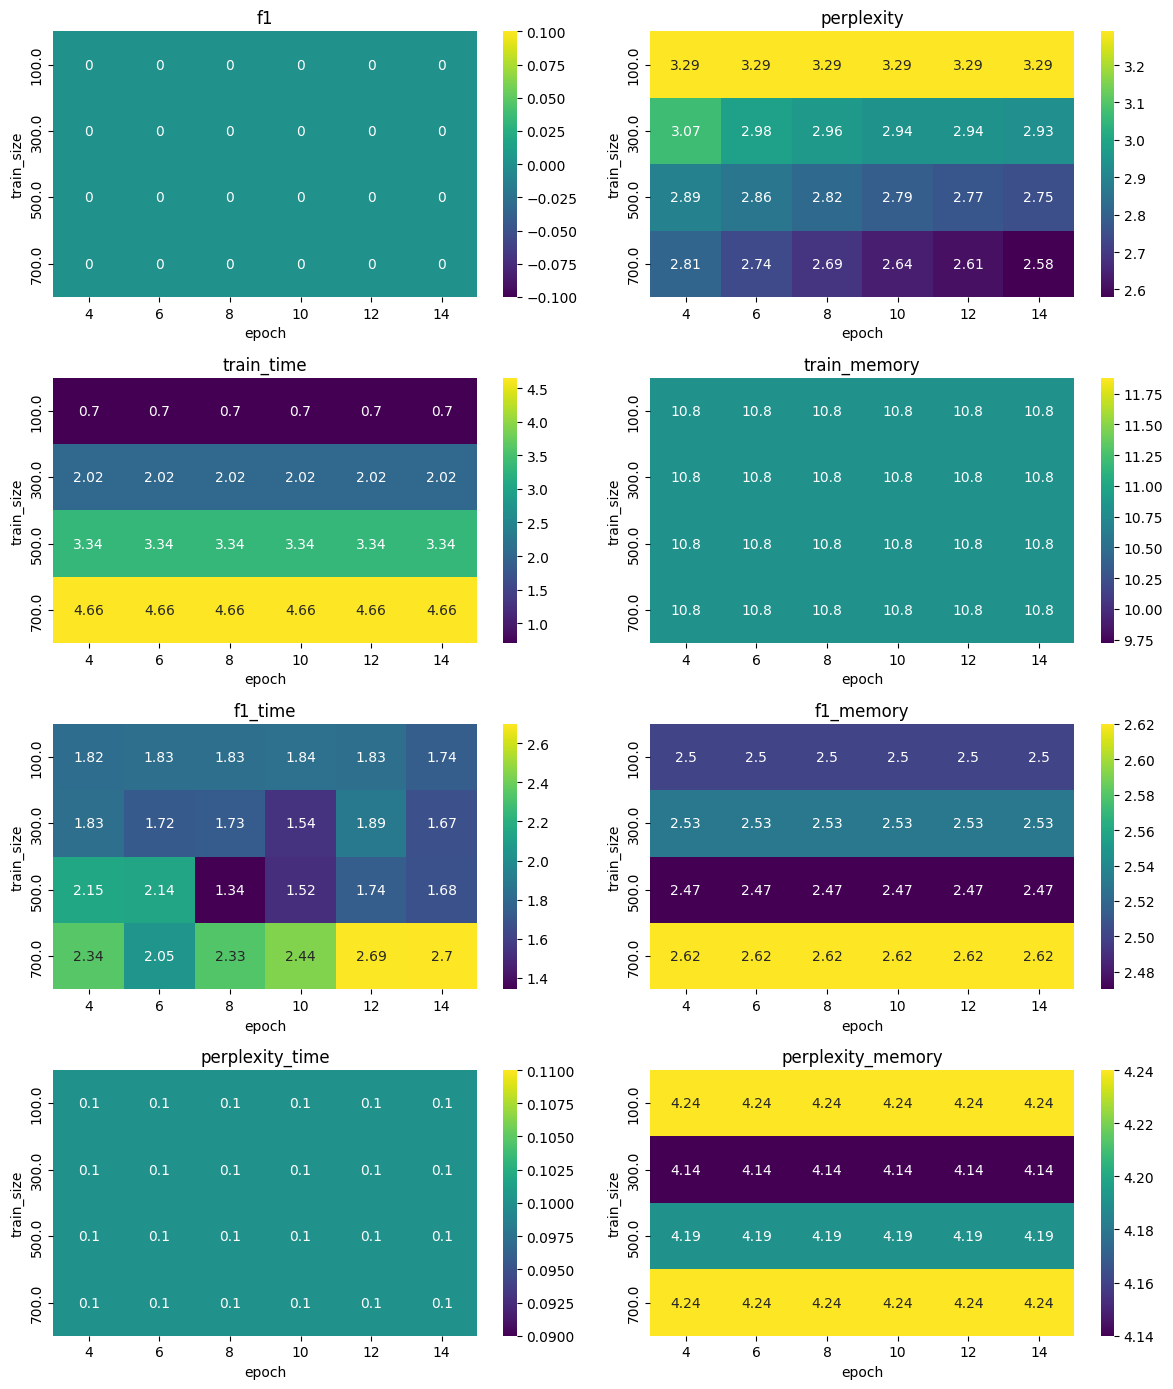

In [41]:

# 3. Все метрики в одном цикле
metrics = ['f1', 'perplexity', 'train_time', 'train_memory',
           'f1_time', 'f1_memory', 'perplexity_time', 'perplexity_memory']

fig, axes = plt.subplots(4, 2, figsize=(12, 14))
axes = axes.flatten()
for ax, metric in zip(axes, metrics):
    pivot = df_long.pivot(index='train_size', columns='epoch', values=metric)
    sns.heatmap(pivot, annot=True, fmt='.3g', cmap='viridis', ax=ax)
    ax.set_title(metric)
    ax.set_xlabel('epoch')
    ax.set_ylabel('train_size')
plt.tight_layout()
plt.show()

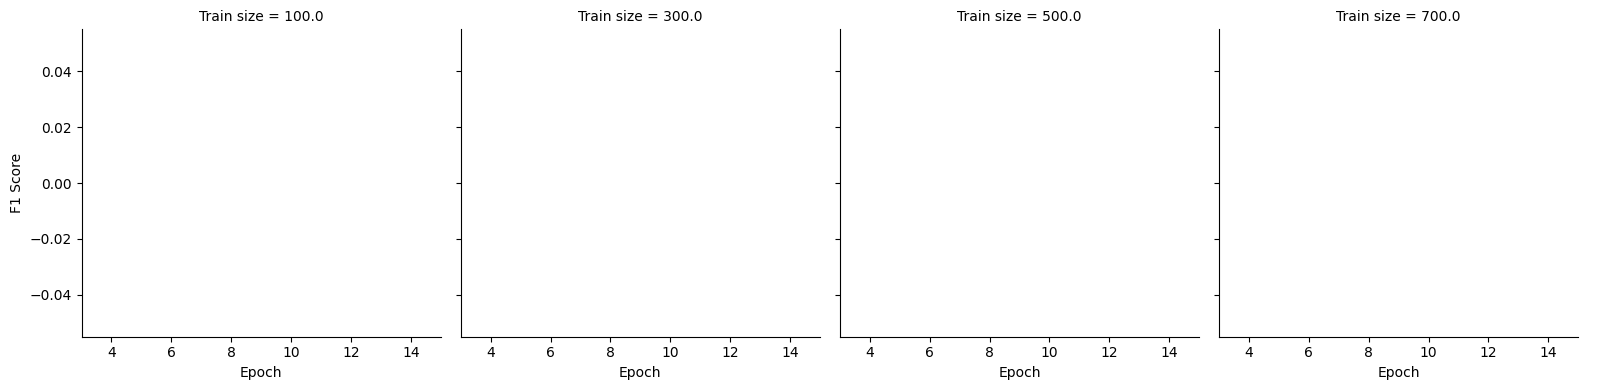

In [42]:
g = sns.catplot(data=df_long, x='epoch', y='f1', col='train_size',
                kind='bar', height=4, aspect=1)
g.set_axis_labels("Epoch", "F1 Score")
g.set_titles("Train size = {col_name}")
plt.show()

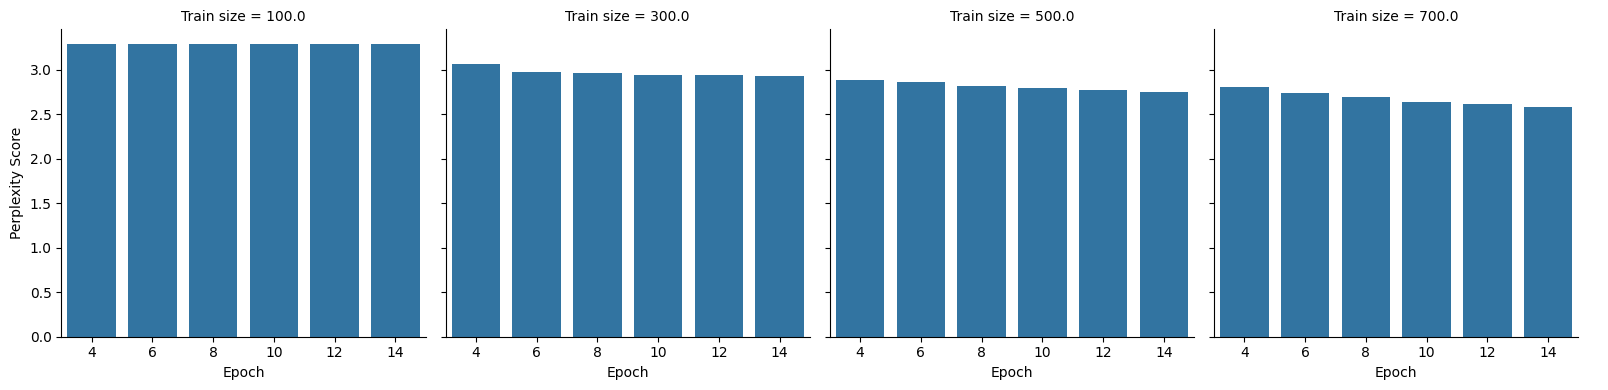

In [43]:
g = sns.catplot(data=df_long, x='epoch', y='perplexity', col='train_size',
                kind='bar', height=4, aspect=1)
g.set_axis_labels("Epoch", "Perplexity Score")
g.set_titles("Train size = {col_name}")
plt.show()

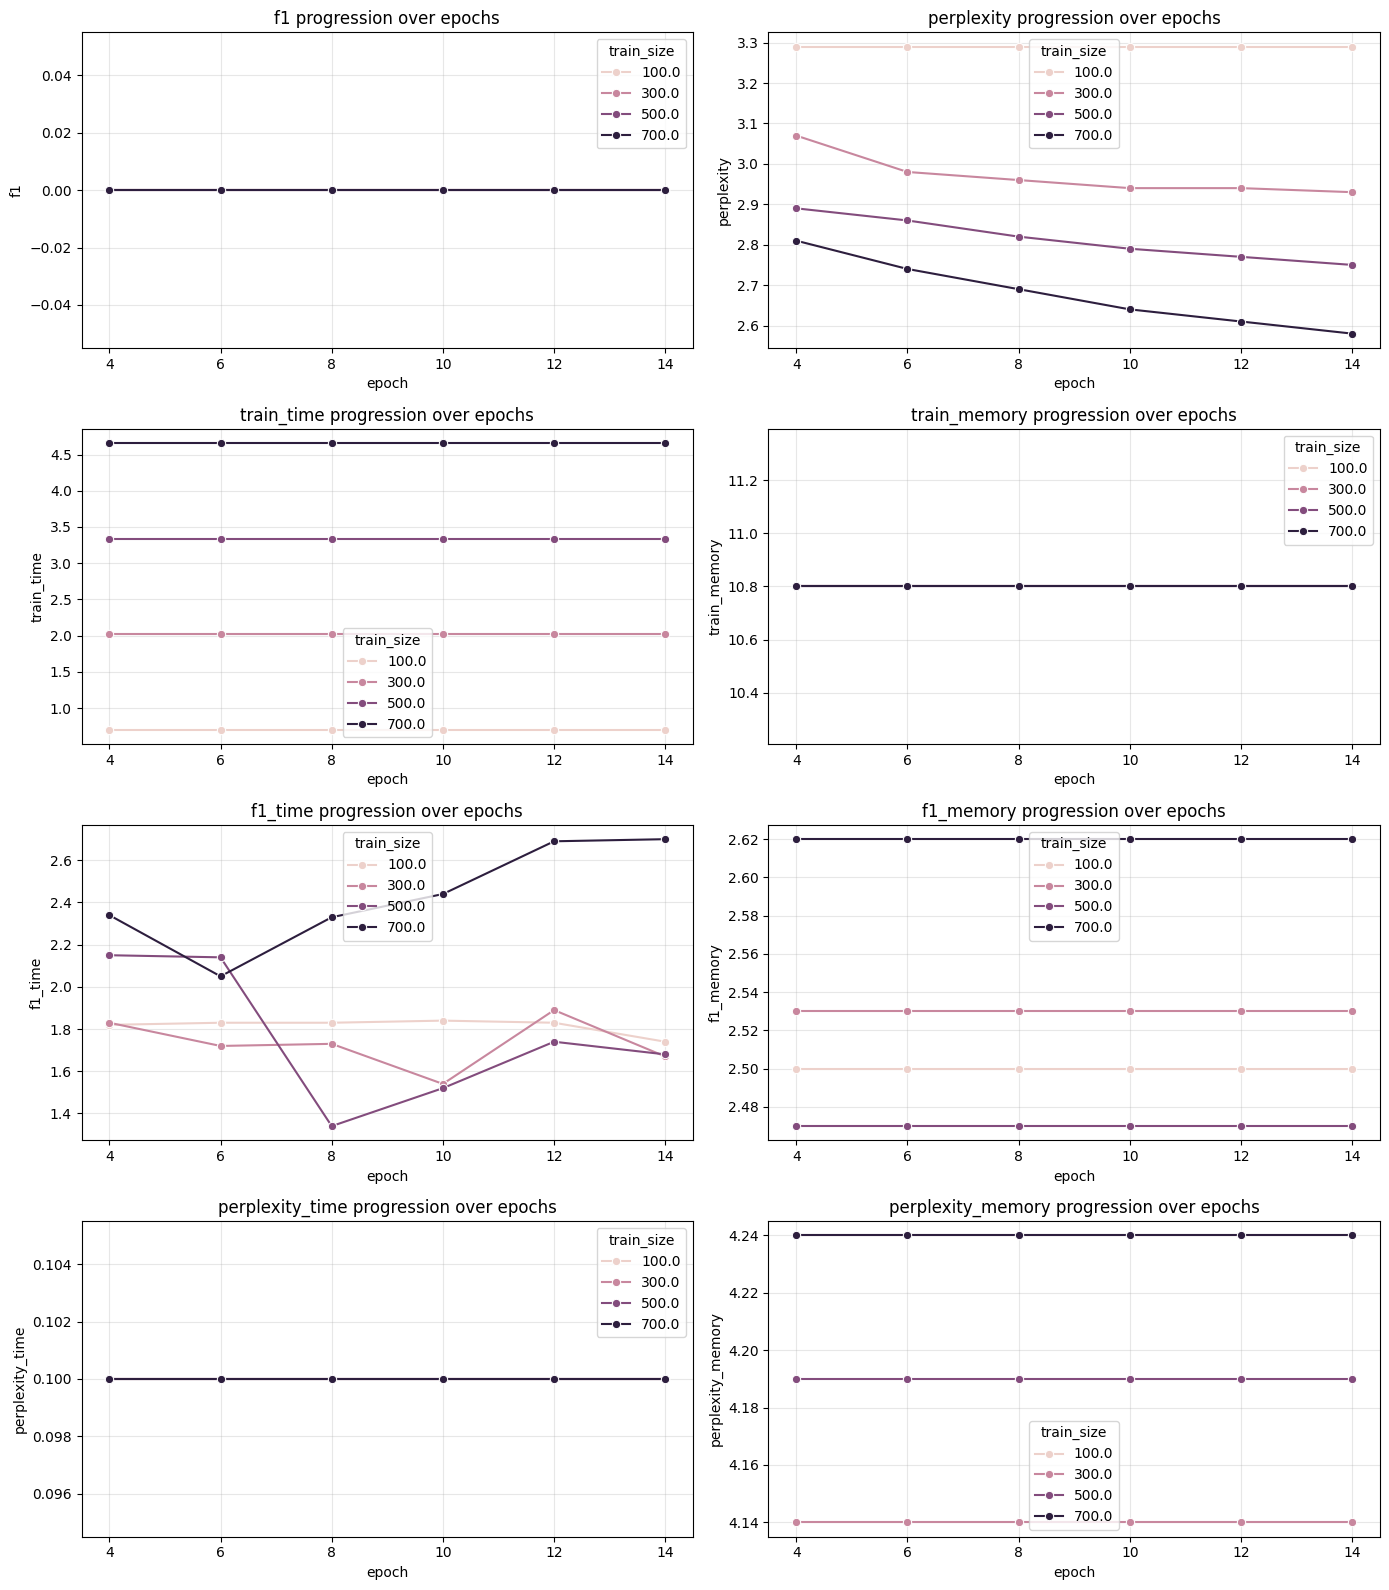

In [44]:
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 16))
axes = axes.flatten()

for i, metric in enumerate(metrics):
    ax = axes[i]
    sns.lineplot(data=df_long, x='epoch', y=metric, hue='train_size',
                 marker='o', ax=ax)
    ax.set_title(f'{metric} progression over epochs')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()